# CLIP Project
## Authors: Adam Bradley and Cole Drumheller

In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-77g96t5_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-77g96t5_
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [2]:
import torch
import clip
from pathlib import Path
import httpx
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from collections import OrderedDict
import torch

We decided to work with a pre-trained model just because it is faster than training one from scratch. It's also going to be a lot better than one that we could throw together in a couple days.

In [3]:
print("Available models:", clip.available_models())
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Input resolution:", input_resolution)
print("Context length:", context_length)
print("Vocab size:", vocab_size)

Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']
Model parameters: 151,277,313
Input resolution: 224
Context length: 77
Vocab size: 49408


In [4]:
preprocess

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x78a14801aa20>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

Below is an example tensor (embedding) of a potential image caption.

In [5]:
clip.tokenize("a picture of a cat")

tensor([[49406,   320,  1674,   539,   320,  2368, 49407,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]], dtype=torch.int32)

We used images from unsplash and staticflickr, this was an easy way to grab some images to work with.

In [6]:
import urllib.parse

def getimg(image_url):
    response = httpx.get(image_url)

    parsed_url = urllib.parse.urlparse(image_url)
    query_params = urllib.parse.parse_qs(parsed_url.query)

    if 'dl' in query_params:
        # Use the filename specified in the 'dl' parameter
        image_name = query_params['dl'][0]
    else:
        # Extract filename from the path component of the URL
        image_name = os.path.basename(parsed_url.path)

    # Save the image to disk
    with open(image_name, "wb") as f:
        f.write(response.content)
    print(f"Image downloaded and saved as {image_name}")

getimg("https://live.staticflickr.com/8340/8225434631_95d566b0e3.jpg")
getimg("https://live.staticflickr.com/3013/2828929673_055ba6a9cc_o.jpg")
getimg("https://images.unsplash.com/photo-1602095656818-c66394568279?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=ilse-orsel-dfQPPSApaIY-unsplash.jpg&w=640")
getimg("https://images.unsplash.com/photo-1555719762-671ca39b6fb0?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=kenny-eliason-IF8B82QBCkM-unsplash.jpg&w=640")
getimg("https://images.unsplash.com/photo-1553969546-6f7388a7e07c?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=josh-gordon-fzHmP6z8OQ4-unsplash.jpg")
getimg("https://images.unsplash.com/photo-1454789548928-9efd52dc4031?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=nasa-Yj1M5riCKk4-unsplash.jpg&w=640")
getimg("https://images.unsplash.com/photo-1521106047354-5a5b85e819ee?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=thomas-jensen-h3vT1Kp0FxA-unsplash.jpg&w=640")
getimg("https://images.unsplash.com/photo-1444858291040-58f756a3bdd6?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=frances-gunn-QcBAZ7VREHQ-unsplash.jpg")
getimg("https://images.unsplash.com/photo-1581281863883-2469417a1668?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=laura-seaman-j-LQfH_zjX8-unsplash.jpg")
getimg("https://images.unsplash.com/photo-1474511320723-9a56873867b5?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=ray-hennessy-xUUZcpQlqpM-unsplash.jpg")
getimg("https://images.unsplash.com/photo-1568526381923-caf3fd520382?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=dmitry-grigoriev-yxXpjF-RrnA-unsplash.jpg")
getimg("https://images.unsplash.com/photo-1528183429752-a97d0bf99b5a?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=simon-wilkes-S297j2CsdlM-unsplash.jpg")




Image downloaded and saved as 8225434631_95d566b0e3.jpg
Image downloaded and saved as 2828929673_055ba6a9cc_o.jpg
Image downloaded and saved as ilse-orsel-dfQPPSApaIY-unsplash.jpg
Image downloaded and saved as kenny-eliason-IF8B82QBCkM-unsplash.jpg
Image downloaded and saved as josh-gordon-fzHmP6z8OQ4-unsplash.jpg
Image downloaded and saved as nasa-Yj1M5riCKk4-unsplash.jpg
Image downloaded and saved as thomas-jensen-h3vT1Kp0FxA-unsplash.jpg
Image downloaded and saved as frances-gunn-QcBAZ7VREHQ-unsplash.jpg
Image downloaded and saved as laura-seaman-j-LQfH_zjX8-unsplash.jpg
Image downloaded and saved as ray-hennessy-xUUZcpQlqpM-unsplash.jpg
Image downloaded and saved as dmitry-grigoriev-yxXpjF-RrnA-unsplash.jpg
Image downloaded and saved as simon-wilkes-S297j2CsdlM-unsplash.jpg


In [7]:
list(Path('.').glob('*.jpg'))

[PosixPath('simon-wilkes-S297j2CsdlM-unsplash.jpg'),
 PosixPath('josh-gordon-fzHmP6z8OQ4-unsplash.jpg'),
 PosixPath('nasa-Yj1M5riCKk4-unsplash.jpg'),
 PosixPath('ray-hennessy-xUUZcpQlqpM-unsplash.jpg'),
 PosixPath('kenny-eliason-IF8B82QBCkM-unsplash.jpg'),
 PosixPath('8225434631_95d566b0e3.jpg'),
 PosixPath('dmitry-grigoriev-yxXpjF-RrnA-unsplash.jpg'),
 PosixPath('frances-gunn-QcBAZ7VREHQ-unsplash.jpg'),
 PosixPath('ilse-orsel-dfQPPSApaIY-unsplash.jpg'),
 PosixPath('thomas-jensen-h3vT1Kp0FxA-unsplash.jpg'),
 PosixPath('2828929673_055ba6a9cc_o.jpg'),
 PosixPath('laura-seaman-j-LQfH_zjX8-unsplash.jpg')]

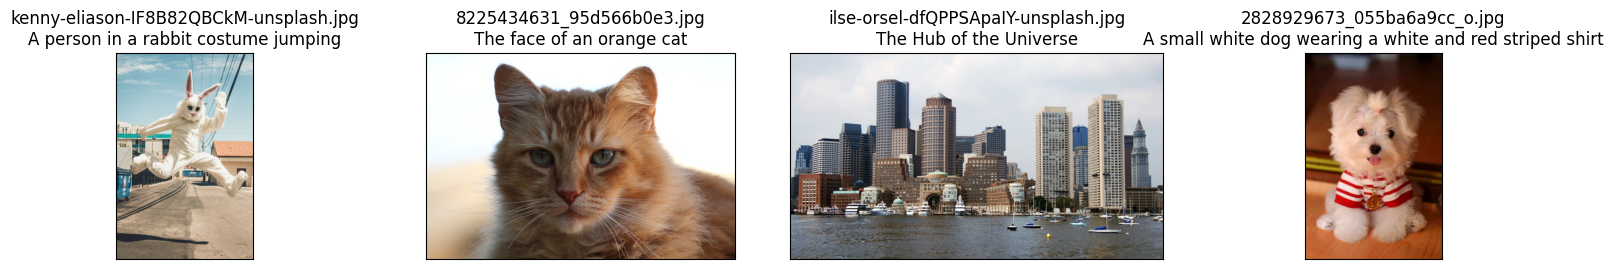

In [ ]:
original_images = []
images = []
texts = []
plt.figure(figsize=(16, 5))

# Define descriptions for each image as a dictionary
descriptions = {
    '8225434631_95d566b0e3': "The face of an orange cat",
    '2828929673_055ba6a9cc_o': "A small white dog wearing a white and red striped shirt",
    'ilse-orsel-dfQPPSApaIY-unsplash': "The Hub of the Universe",
    'kenny-eliason-IF8B82QBCkM-unsplash': 'A person in a rabbit costume jumping',
}

# Process each image file in the current directory
for filename in Path('.').glob('*.jpg'):
    name = filename.stem
    if name not in descriptions:
        continue
    # load and convert the image to RGB
    image = Image.open(filename).convert("RGB")

    # Display the original image with its description
    plt.subplot(2, 4, len(images) + 1)
    plt.imshow(image)
    plt.title(f"{filename}\n{descriptions[name]}")
    plt.xticks([])
    plt.yticks([])

    original_images.append(image)
    images.append(preprocess(image))
    texts.append(descriptions[name])

plt.tight_layout()


We're working with the above images, below we have the model encode both the images themselves along with their captions in order to get the images latent space embedding and the text's embedding.

In [ ]:
image_input = torch.tensor(np.stack(images)).cuda()
text_tokens = clip.tokenize(["This is " + desc for desc in texts]).cuda()
with torch.no_grad():
    # encode images and texts to get their embeddings
    image_features = model.encode_image(image_input).float()
    text_features = model.encode_text(text_tokens).float()

image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
# Compute cosine similarity between text and image features
similarity = text_features.cpu().numpy() @ image_features.cpu().numpy().T

Text(0.5, 1.0, 'Cosine similarity between text and image features')

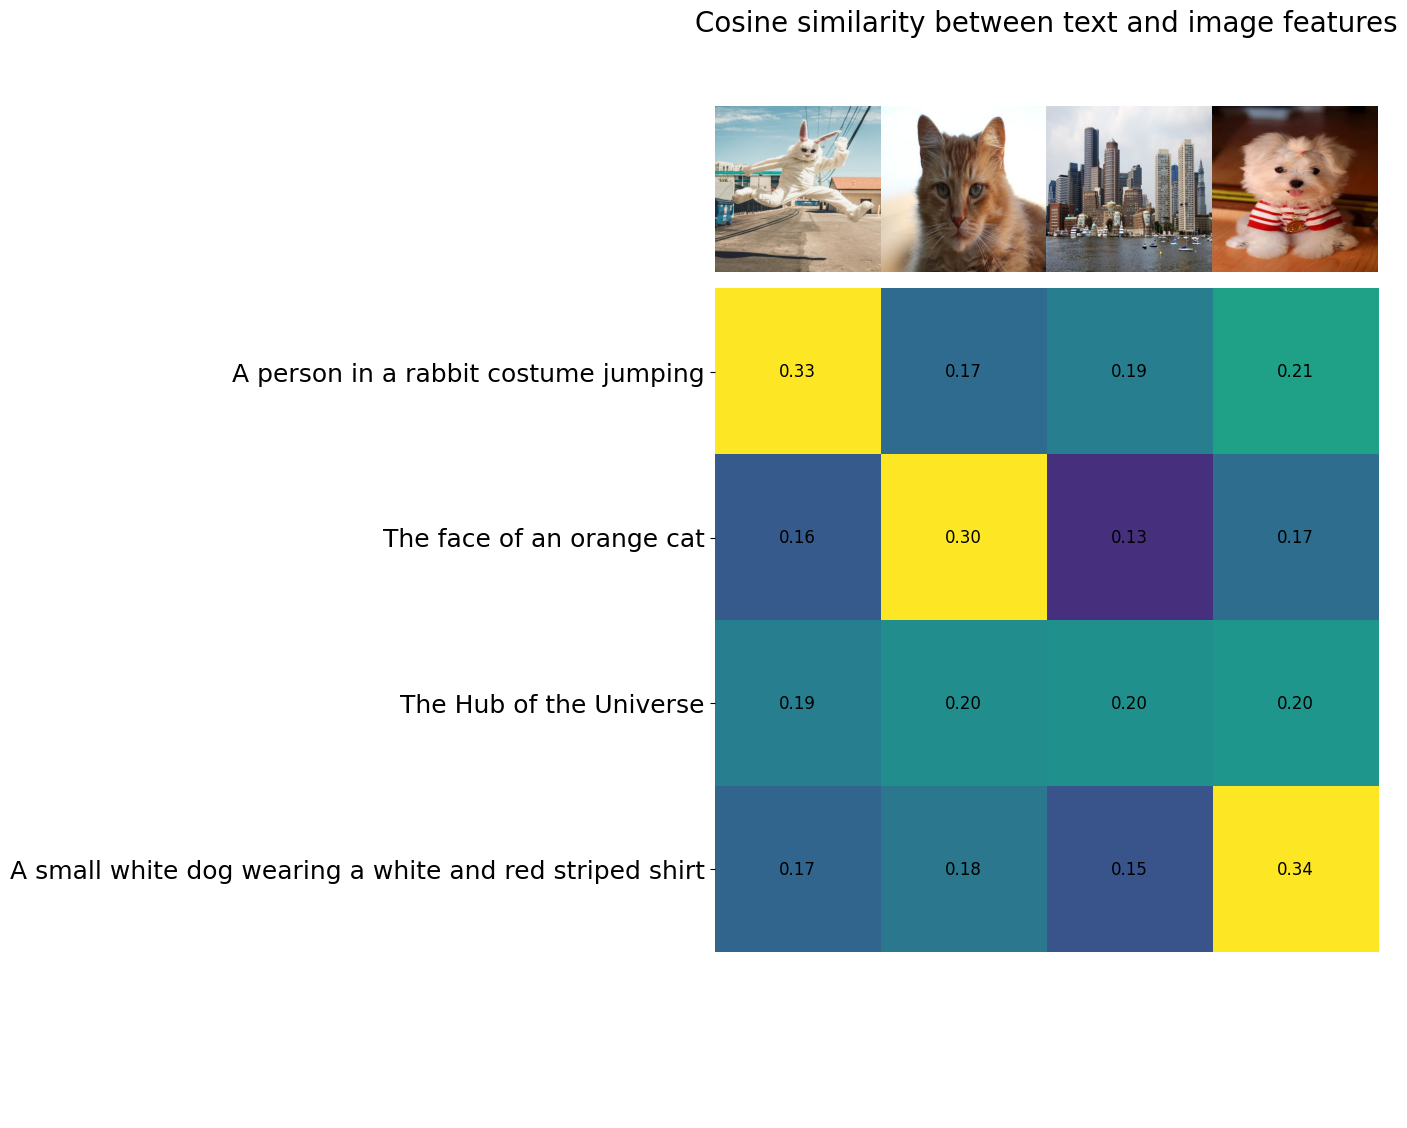

In [ ]:
count = len(descriptions)

# Visualize the cosine similarity matrix
plt.figure(figsize=(20, 14))
plt.imshow(similarity, vmin=0.1, vmax=0.3)
# plt.colorbar()
plt.yticks(range(count), texts, fontsize=18)
plt.xticks([])
for i, image in enumerate(original_images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
  plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)

In the above matrix we display the similarity values between the images and the captions. 3 of the 4 image correctly have the max value on the correct caption. The one that struggled, it doesn't really surprise me that it struggled because "The Hub of the Universe" is pretty vague, like I wouldn't describe an image that looked like that if you told me to show the "Hub of the Universe".

In [11]:
from torchvision.datasets import CIFAR100

cifar100 = CIFAR100(os.path.expanduser("~/.cache"), transform=preprocess, download=True)
text_descriptions = [f"This is a photo of a {label}" for label in cifar100.classes]


Now we switch to working with the CIFAR100 dataset, using it in python is simple and we easily set the text_descriptions by using the label for each picture.

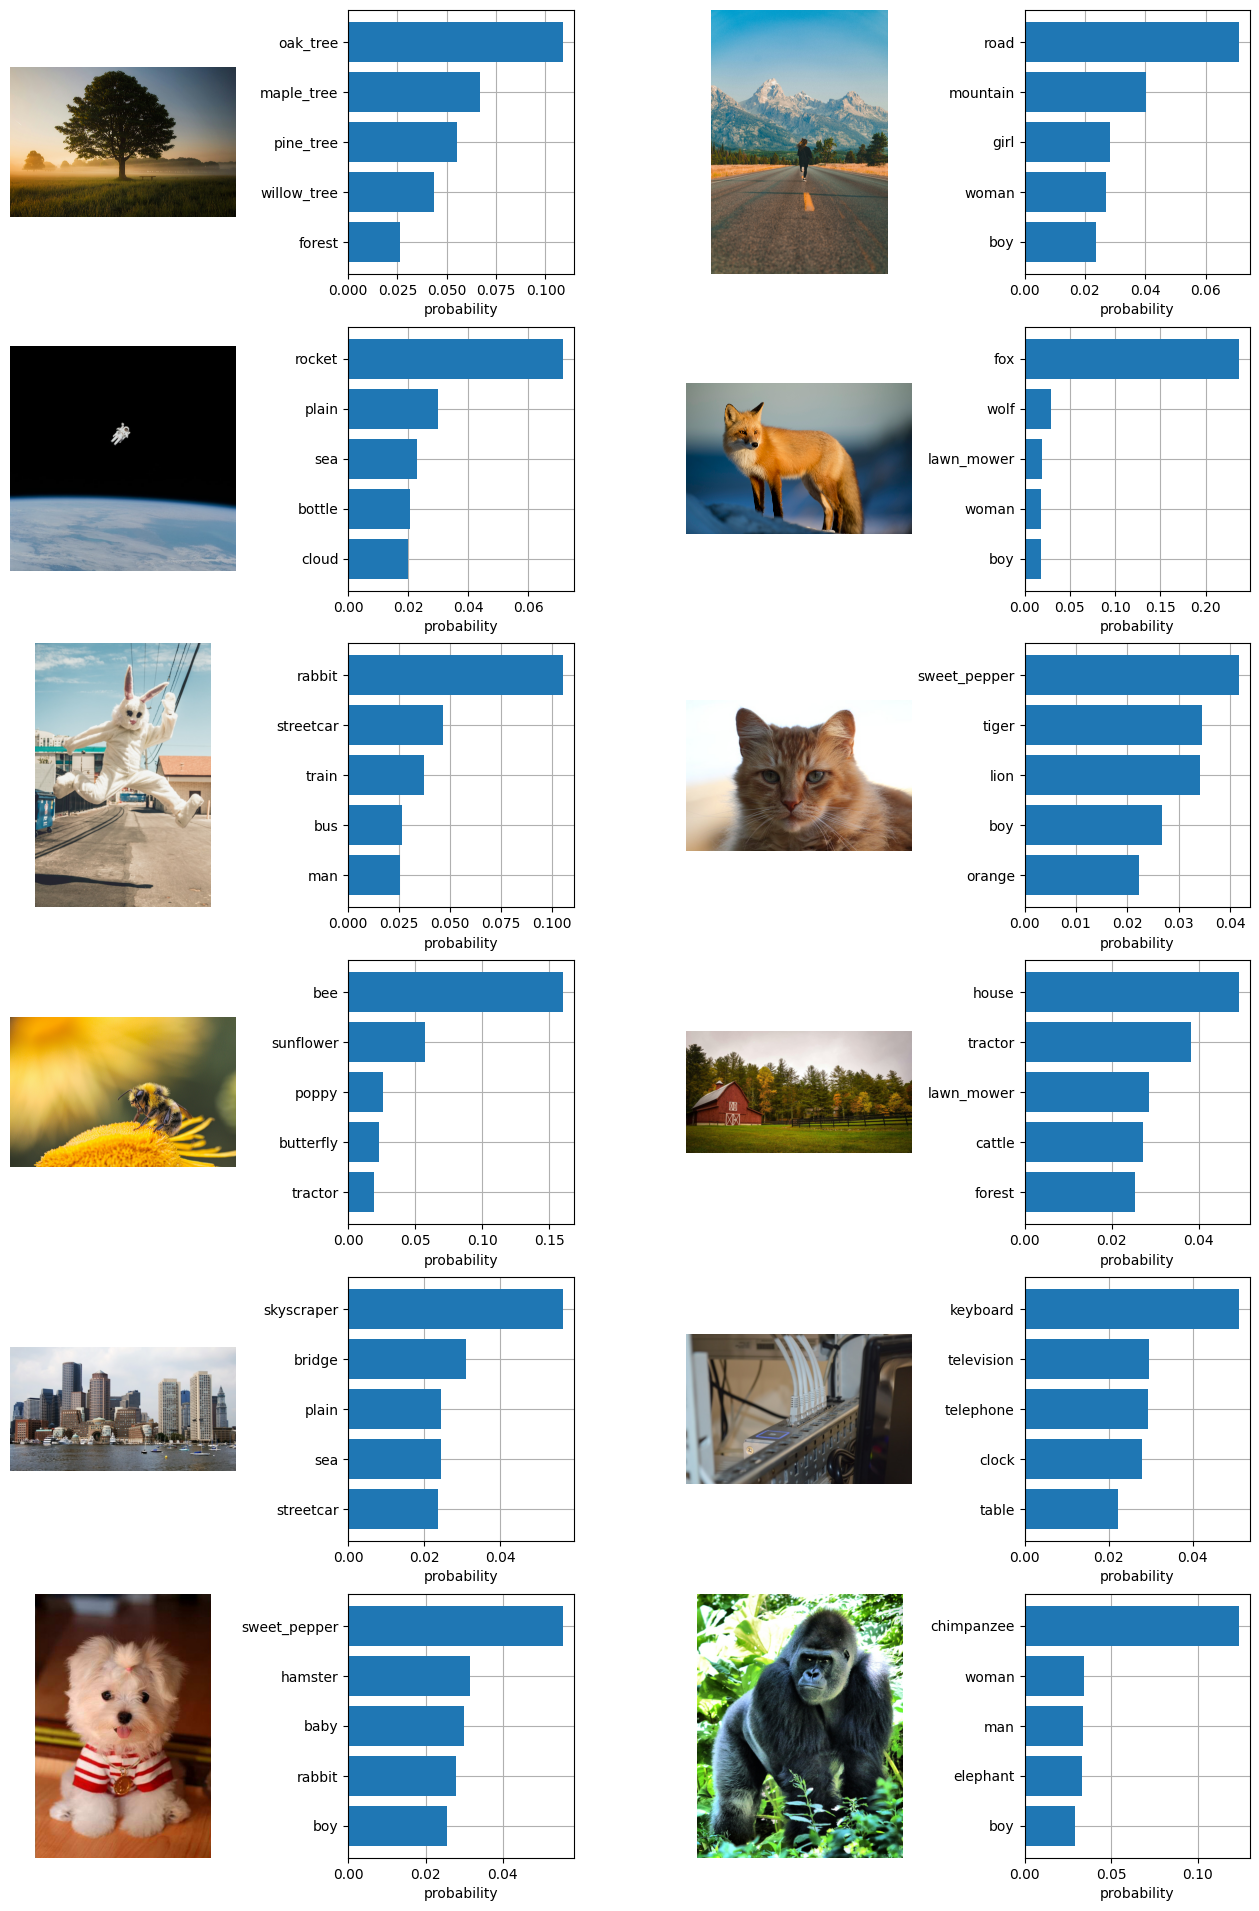

In [ ]:
image_files = list(Path('.').glob('*.jpg'))

# Preprocess all images found in the directory
images_list = [preprocess(Image.open(f).convert("RGB")) for f in image_files]
image_input = torch.tensor(np.stack(images_list)).to(device)

# Tokenize the CIFAR100 descriptions (100 classes)
text_tokens = clip.tokenize(text_descriptions).to(device)

with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    text_features = model.encode_text(text_tokens).float()

    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# Use 30.0 scaling to see distribution (instead of 100.0)
text_probs = (30.0 * image_features @ text_features.T).softmax(dim=-1)
top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

# Dynamic layout calculation
num_images = len(image_files)
# Calculate rows needed (2 plots per image, 4 plots per row means 2 images per row)
num_rows = int(np.ceil(num_images / 2.0))

plt.figure(figsize=(16, 4 * num_rows))

for i, filename in enumerate(image_files):
    # Load the raw image for visualization
    image = Image.open(filename).convert("RGB")

    # Plot image and its top predictions
    plt.subplot(num_rows, 4, 2 * i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(num_rows, 4, 2 * i + 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs[i])
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [cifar100.classes[index] for index in top_labels[i].numpy()])
    plt.xlabel("probability")

plt.subplots_adjust(wspace=0.5)
plt.show()

The above plots show the probabilities of several possible labels for each picture. Most of these do pretty well, but I want to talk about the 2 that are really off. The cat and dog both get predicted to match the label of "sweet_pepper", I'm at a loss of how this could've happened but I think it's pretty funny. The other ones that it got wrong were understandable, it labeled the astronaut as a rocket, but I can see how it would come to that. White object on black background of space, rocket makes sense. The plugged in wires getting matched to keyboard is a little far off as well, but it's not a very clear picture of a single thing so I can see why it struggled there. Then it also matched the gorilla with a label of chimpanzee, pretty close.

#`sweet_pepper`?

In [ ]:
# Select the first image and text embedding as an example
idx = 0
# function to get similarity between image and text
def show_similarity(idx, description):
    image_embedding = image_features[idx]
    text_embedding = model.encode_text(clip.tokenize(description).to(device))[0]

    similarity_func = torch.nn.functional.cosine_similarity(
        image_embedding.unsqueeze(0),
        text_embedding.unsqueeze(0)
    ).item()

    print(f"Cosine Similarity (Function):    {similarity_func:.4f}")

    # Display the image
    image_files = list(Path('.').glob('*.jpg'))
    image_path = image_files[idx]
    image = Image.open(image_path).convert("RGB")
    # plot image and its similarity
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Text: '{description}'\nSimilarity: {similarity_func:.4f}")
    plt.axis('off')
    plt.show()

Below is more similarity testing, I thought it was interesting that the generic skyline picture actually matched better to a more specific label in "Boston" than it did to a vague label in "a city skyline".

Cosine Similarity (Function):    0.3046


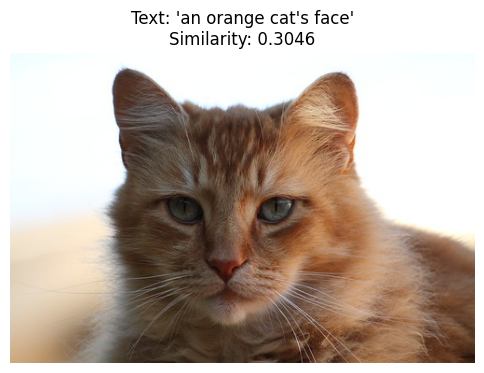

In [14]:
show_similarity(5, "an orange cat's face")

Cosine Similarity (Function):    0.2668


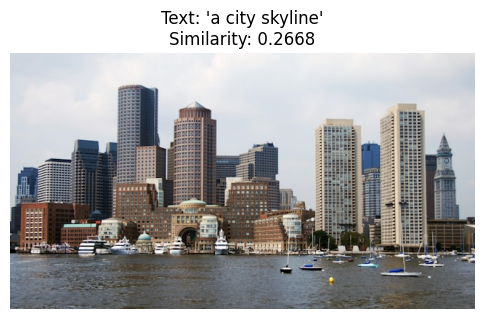

In [15]:
show_similarity(8, "a city skyline")

Cosine Similarity (Function):    0.3000


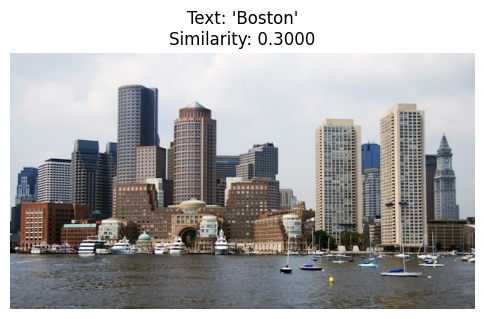

In [16]:
show_similarity(8, "Boston")